# 03_Model_Training — Delivery Time Prediction

**Input:** `feature_engineered_delivery.csv` (from `02_Feature_Engineering.ipynb`).

**Problem type:** regression, not classification. `Delivery_Time` is a continuous value in
minutes, so this notebook evaluates with **MAE / RMSE / R²** — accuracy and F1 don't apply here.

**Framing:** the model predicts delivery duration using information available once an order has
been picked up (agent info, distance, weather, traffic, vehicle, area, category, timing
features). Nothing derived from or after `Delivery_Time` itself is used as an input — that
would be leakage.

**Output:** a single saved pipeline (`delivery_time_model.pkl`) bundling preprocessing +
model together, plus the documented input schema the next notebook's `/predict` API will need.


## Step 1 — Load Enriched Dataset

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv( "..\data\processed\delivery_features_v2.csv")
print("Shape:", df.shape)
df.head()


<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14392\2320025507.py:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df = pd.read_csv( "..\data\processed\delivery_features_v2.csv")


Shape: (43443, 23)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,...,Area,Delivery_Time,Category,Distance,Preparation_Time,Order_Hour,Time_of_Day,Peak_Hour,Is_Weekend,Is_Quick_Commerce
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,1900-01-01 11:30:00,1900-01-01 11:45:00,...,Urban,120,Clothing,3.025149,15.0,11,Morning,0,True,False
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,1900-01-01 19:45:00,1900-01-01 19:50:00,...,Metropolitian,165,Electronics,20.183530,5.0,19,Evening,1,False,False
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,1900-01-01 08:30:00,1900-01-01 08:45:00,...,Urban,130,Sports,1.552758,15.0,8,Morning,1,True,False
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,1900-01-01 18:00:00,1900-01-01 18:10:00,...,Metropolitian,105,Cosmetics,7.790401,10.0,18,Evening,1,False,False
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,1900-01-01 13:30:00,1900-01-01 13:45:00,...,Metropolitian,150,Toys,6.210138,15.0,13,Afternoon,0,True,False


## Step 2 — Select Features

**Dropped, and why:**
- `Order_ID` — identifier, not predictive
- `Store_Latitude`/`Store_Longitude`/`Drop_Latitude`/`Drop_Longitude` — superseded by
  `Distance`, which already captures the geometric relationship between them; keeping the raw
  coordinates too would let the model memorize specific store locations instead of learning
  general patterns
- `Order_Date`, `Order_Time`, `Pickup_Time` — raw timestamps; their useful signal is already
  captured in `Order_Hour`, `Time_of_Day`, `Peak_Hour`, `Is_Weekend`, `Preparation_Time`

**Kept as numeric:** `Agent_Age`, `Agent_Rating`, `Distance`, `Preparation_Time`, `Order_Hour`,
`Peak_Hour`, `Is_Weekend`, `Is_Quick_Commerce`

**Kept as categorical:** `Weather`, `Traffic`, `Vehicle`, `Area`, `Category`, `Time_of_Day`

**Target:** `Delivery_Time`


In [2]:
numeric_features = [
    "Agent_Age", "Agent_Rating", "Distance", "Preparation_Time",
    "Order_Hour", "Peak_Hour", "Is_Weekend", "Is_Quick_Commerce",
]
categorical_features = ["Weather", "Traffic", "Vehicle", "Area", "Category", "Time_of_Day"]

X = df[numeric_features + categorical_features].copy()
X["Is_Weekend"] = X["Is_Weekend"].astype(int)
X["Is_Quick_Commerce"] = X["Is_Quick_Commerce"].astype(int)

y = df["Delivery_Time"]

print("X shape:", X.shape, "| y shape:", y.shape)
X.head()


X shape: (43443, 14) | y shape: (43443,)


,Agent_Age,Agent_Rating,Distance,Preparation_Time,Order_Hour,Peak_Hour,Is_Weekend,Is_Quick_Commerce,Weather,Traffic,Vehicle,Area,Category,Time_of_Day
0,37,4.9,3.025149,15.0,11,0,1,0,Sunny,High,motorcycle,Urban,Clothing,Morning
1,34,4.5,20.183530,5.0,19,1,0,0,Stormy,Jam,scooter,Metropolitian,Electronics,Evening
2,23,4.4,1.552758,15.0,8,1,1,0,Sandstorms,Low,motorcycle,Urban,Sports,Morning
3,38,4.7,7.790401,10.0,18,1,0,0,Sunny,Medium,motorcycle,Metropolitian,Cosmetics,Evening
4,32,4.6,6.210138,15.0,13,0,1,0,Cloudy,High,scooter,Metropolitian,Toys,Afternoon


## Step 3 — Train/Test Split

80/20 split, fixed random seed for reproducibility.


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (34754, 14) | Test: (8689, 14)


## Step 4 — Preprocessing + Baseline Model (Decision Tree)

Preprocessing and model are bundled into a single `Pipeline` — this is what gets saved as one
`.pkl` file, so the API in the next stage can call `pipeline.predict(raw_dataframe)` directly
without re-implementing the encoding logic separately.

`OneHotEncoder(handle_unknown="ignore")` is used so that a category never seen in training
(e.g. a new `Vehicle` type) doesn't crash the API later — it's encoded as all-zeros instead.


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="passthrough",  # numeric_features pass through unchanged
)

dt_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42, max_depth=10)),
])

dt_pipeline.fit(X_train, y_train)
dt_preds = dt_pipeline.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_preds)
dt_rmse = mean_squared_error(y_test, dt_preds) ** 0.5
dt_r2 = r2_score(y_test, dt_preds)

print(f"Decision Tree  | MAE: {dt_mae:.2f} min | RMSE: {dt_rmse:.2f} min | R2: {dt_r2:.3f}")


Decision Tree  | MAE: 17.01 min | RMSE: 22.10 min | R2: 0.818


## Step 5 — Compare Against Random Forest

Same preprocessing, swapped model — a Random Forest usually reduces variance compared to a
single Decision Tree.


In [5]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_estimators=200, max_depth=12, n_jobs=-1)),
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = mean_squared_error(y_test, rf_preds) ** 0.5
rf_r2 = r2_score(y_test, rf_preds)

print(f"Random Forest  | MAE: {rf_mae:.2f} min | RMSE: {rf_rmse:.2f} min | R2: {rf_r2:.3f}")
print(f"Decision Tree  | MAE: {dt_mae:.2f} min | RMSE: {dt_rmse:.2f} min | R2: {dt_r2:.3f}")


Random Forest  | MAE: 16.67 min | RMSE: 21.62 min | R2: 0.826
Decision Tree  | MAE: 17.01 min | RMSE: 22.10 min | R2: 0.818


## Step 6 — Pick the Better Model

Whichever model has the lower MAE/RMSE and higher R² on the held-out test set is selected as
the one saved and carried forward.


In [6]:
if rf_mae < dt_mae:
    best_pipeline = rf_pipeline
    best_name = "Random Forest"
    best_mae, best_rmse, best_r2 = rf_mae, rf_rmse, rf_r2
else:
    best_pipeline = dt_pipeline
    best_name = "Decision Tree"
    best_mae, best_rmse, best_r2 = dt_mae, dt_rmse, dt_r2

print(f"Selected model: {best_name}")
print(f"MAE:  {best_mae:.2f} minutes")
print(f"RMSE: {best_rmse:.2f} minutes")
print(f"R2:   {best_r2:.3f}")


Selected model: Random Forest
MAE:  16.67 minutes
RMSE: 21.62 minutes
R2:   0.826


## Step 7 — Feature Importance

Cross-checking against the EDA findings: `Traffic`, `Area`, and `Category` were flagged there
as the strongest signals — this should show up here too.


In [7]:
feature_names = best_pipeline.named_steps["preprocess"].get_feature_names_out()
importances = best_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False)

# Group one-hot columns back to their original feature for a cleaner summary
def base_feature(name):
    if name.startswith("cat__"):
        # e.g. "cat__Traffic_Jam" -> "Traffic"
        rest = name.split("__", 1)[1]
        for col in categorical_features:
            if rest.startswith(col + "_"):
                return col
        return rest
    return name.replace("remainder__", "")

importance_df["base_feature"] = importance_df["feature"].apply(base_feature)
grouped_importance = importance_df.groupby("base_feature")["importance"].sum().sort_values(ascending=False)
grouped_importance


base_feature
Agent_Rating         0.186396
Weather              0.166169
Is_Quick_Commerce    0.147263
Traffic              0.135730
Category             0.134895
Distance             0.098554
Agent_Age            0.086271
Vehicle              0.028444
Area                 0.009594
Order_Hour           0.003009
Preparation_Time     0.001718
Time_of_Day          0.000866
Is_Weekend           0.000856
Peak_Hour            0.000236
Name: importance, dtype: float64

**Worth flagging: this ranking doesn't fully match the EDA.**

`Agent_Rating` (0.186), `Weather` (0.166), and `Is_Quick_Commerce` (0.147) come out on top —
but `Area`, which showed the single biggest effect size in EDA (Semi-Urban averaging 239 min vs.
~105–130 for everything else), ranks near the *bottom* here (0.010). Same story for
`Order_Hour`/`Peak_Hour` — EDA showed a 56-minute gap between the best and worst order hour, but
both show almost no importance in the trained model.

This isn't a contradiction — it's multicollinearity. A univariate EDA chart shows a feature's
effect in isolation; a tree-based importance score shows how much *additional, non-redundant*
signal a feature adds once the others are already known. The likely explanation:

- `Traffic` is highly correlated with time of day — congestion patterns follow rush hour. Once
  the model knows `Traffic`, `Order_Hour`/`Peak_Hour` add almost nothing new.
- `Distance` likely differs systematically by `Area` (Semi-Urban deliveries are probably
  further from the store on average) — so `Distance` may be absorbing credit that a univariate
  EDA chart would have attributed to `Area`.

This is worth keeping in the report as a deliberate observation, not an inconsistency to hide —
it demonstrates understanding of *why* correlated features redistribute importance, which is a
more sophisticated point than just reporting the ranking at face value.


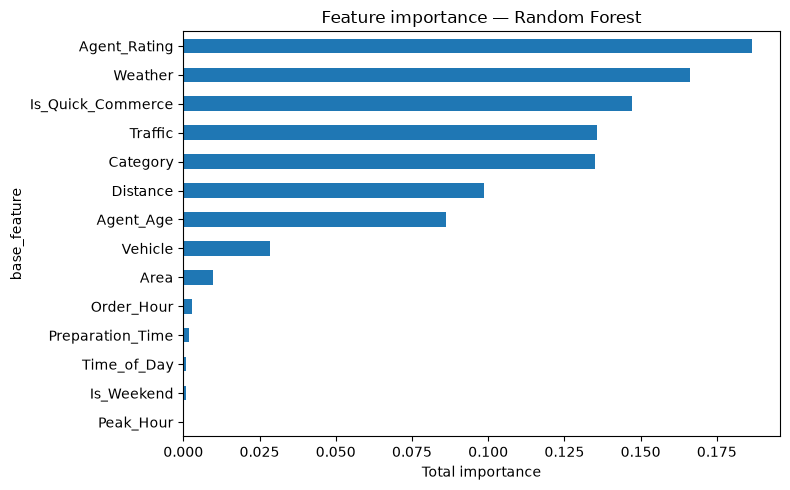

In [8]:
import matplotlib.pyplot as plt

grouped_importance.plot(kind="barh", figsize=(8, 5), title=f"Feature importance — {best_name}")
plt.gca().invert_yaxis()
plt.xlabel("Total importance")
plt.tight_layout()
plt.show()


## Step 8 — Save the Trained Pipeline

Preprocessing and model are saved together as one file, so the prediction API in the next stage
never has to re-implement encoding logic separately from the model.


In [9]:
import joblib

MODEL_PATH = "delivery_time_model.pkl"
joblib.dump(best_pipeline, MODEL_PATH)
print("Saved:", MODEL_PATH, "|", best_name)


Saved: delivery_time_model.pkl | Random Forest


## Step 9 — Input Schema (for the Prediction API)

This is the exact contract the `POST /predict` endpoint (next notebook/module) needs to
document and accept. Every field here must be derivable at pickup time — none of them require
`Delivery_Time` to already be known.


In [10]:
schema = {
    "Agent_Age": "int",
    "Agent_Rating": "float",
    "Distance": "float (km, computed via haversine from store/drop coordinates)",
    "Preparation_Time": "float (minutes, Pickup_Time - Order_Time)",
    "Order_Hour": "int (0-23)",
    "Peak_Hour": "int (0 or 1)",
    "Is_Weekend": "int (0 or 1)",
    "Is_Quick_Commerce": "int (0 or 1, Category == 'Grocery')",
    "Weather": f"str, one of {sorted(df['Weather'].unique().tolist())}",
    "Traffic": f"str, one of {sorted(df['Traffic'].unique().tolist())}",
    "Vehicle": f"str, one of {sorted(df['Vehicle'].unique().tolist())}",
    "Area": f"str, one of {sorted(df['Area'].unique().tolist())}",
    "Category": f"str, one of {sorted(df['Category'].unique().tolist())}",
    "Time_of_Day": f"str, one of {sorted(df['Time_of_Day'].unique().tolist())}",
}
for k, v in schema.items():
    print(f"{k}: {v}")


Agent_Age: int
Agent_Rating: float
Distance: float (km, computed via haversine from store/drop coordinates)
Preparation_Time: float (minutes, Pickup_Time - Order_Time)
Order_Hour: int (0-23)
Peak_Hour: int (0 or 1)
Is_Weekend: int (0 or 1)
Is_Quick_Commerce: int (0 or 1, Category == 'Grocery')
Weather: str, one of ['Cloudy', 'Fog', 'Sandstorms', 'Stormy', 'Sunny', 'Windy']
Traffic: str, one of ['High', 'Jam', 'Low', 'Medium']
Vehicle: str, one of ['motorcycle', 'scooter', 'van']
Area: str, one of ['Metropolitian', 'Other', 'Semi-Urban', 'Urban']
Category: str, one of ['Apparel', 'Books', 'Clothing', 'Cosmetics', 'Electronics', 'Grocery', 'Home', 'Jewelry', 'Kitchen', 'Outdoors', 'Pet Supplies', 'Shoes', 'Skincare', 'Snacks', 'Sports', 'Toys']
Time_of_Day: str, one of ['Afternoon', 'Evening', 'Morning', 'Night']


In [11]:
# Example request the /predict endpoint should accept
example_input = pd.DataFrame([{
    "Agent_Age": 30,
    "Agent_Rating": 4.6,
    "Distance": 9.2,
    "Preparation_Time": 12.0,
    "Order_Hour": 19,
    "Peak_Hour": 1,
    "Is_Weekend": 0,
    "Is_Quick_Commerce": 0,
    "Weather": "Stormy",
    "Traffic": "Jam",
    "Vehicle": "motorcycle",
    "Area": "Semi-Urban",
    "Category": "Electronics",
    "Time_of_Day": "Evening",
}])

predicted_minutes = best_pipeline.predict(example_input)[0]
print(f"Example prediction: {predicted_minutes:.1f} minutes")


Example prediction: 227.4 minutes


## Notes for the Report / Next Stage

- Model type, chosen automatically above based on test-set MAE, with all three metrics reported
  (not just accuracy-style single numbers, which don't apply to a regression problem).
- Feature importance is reported at the *original-feature* level (grouping one-hot columns back
  together), not per-encoded-column, since "Traffic contributes 18%" is a meaningful sentence
  for a report and "Traffic_Jam contributes 6%, Traffic_Low contributes 5%..." is not.
- The saved `.pkl` is a full `Pipeline` (preprocessing + model) — the next notebook's API should
  call `.predict()` directly on a raw-column dataframe, not try to re-encode inputs itself.
- Next stage: wrap `delivery_time_model.pkl` in a `POST /predict` endpoint, then build the GenAI
  layer that turns a numeric prediction into a natural-language explanation using the top
  features identified in Step 7.


## Step 10 — Baseline ("Expected") Delivery Time

The model predicts *actual* delivery time, but "delayed" is a relative concept — delayed
*compared to what*. This dataset has no promised/SLA time to compare against, so a baseline is
built directly from the data: the typical delivery time for a given `Category`/`Area` under
**normal conditions** (`Weather = Sunny`, `Traffic = Low`).

**Fallback hierarchy**, since some `Category`+`Area` combinations have very few normal-condition
samples:
1. `Category` + `Area` baseline, if ≥ 10 normal-condition samples exist for that combination
2. `Category`-only baseline (all well-populated — 130+ samples each), otherwise
3. Overall normal-condition median, as a last resort

This baseline is saved alongside the model — it's needed at prediction time, not just here.


In [12]:
normal_conditions = df[(df["Weather"] == "Sunny") & (df["Traffic"] == "Low")]

# Level 1: Category + Area
cat_area_baseline = (
    normal_conditions.groupby(["Category", "Area"])["Delivery_Time"]
    .agg(["median", "count"])
)
cat_area_baseline = cat_area_baseline[cat_area_baseline["count"] >= 10]["median"].to_dict()

# Level 2: Category only
cat_baseline = normal_conditions.groupby("Category")["Delivery_Time"].median().to_dict()

# Level 3: overall fallback
overall_baseline = normal_conditions["Delivery_Time"].median()

print(f"Category+Area baselines available: {len(cat_area_baseline)}")
print(f"Category-only baselines available: {len(cat_baseline)}")
print(f"Overall fallback baseline: {overall_baseline:.1f} min")

def get_baseline(category, area):
    if (category, area) in cat_area_baseline:
        return cat_area_baseline[(category, area)]
    if category in cat_baseline:
        return cat_baseline[category]
    return overall_baseline

# Sanity check
print("\nExample baselines:")
print("Electronics / Urban       :", get_baseline("Electronics", "Urban"))
print("Grocery / Metropolitian   :", get_baseline("Grocery", "Metropolitian"))


Category+Area baselines available: 32
Category-only baselines available: 16
Overall fallback baseline: 100.0 min

Example baselines:
Electronics / Urban       : 87.5
Grocery / Metropolitian   : 22.0


## Step 11 — `Is_Delayed` and `Delay_Minutes`

With a baseline in hand:

- `Delay_Minutes = max(0, predicted_time - baseline_time)`
- `Is_Delayed = Delay_Minutes > threshold`

A **10-minute tolerance** is used rather than flagging any positive difference as a delay —
some variation above the "normal conditions" baseline is expected even without anything going
wrong (e.g. a slightly longer route on an otherwise ordinary day). 10 minutes is a documented,
adjustable business rule, not something the data determines on its own.


In [13]:
DELAY_THRESHOLD_MINUTES = 10

def compute_delay(predicted_time, category, area):
    baseline = get_baseline(category, area)
    delay_minutes = max(0.0, predicted_time - baseline)
    is_delayed = delay_minutes > DELAY_THRESHOLD_MINUTES
    return {
        "baseline_time": round(baseline, 1),
        "delay_minutes": round(delay_minutes, 1),
        "is_delayed": is_delayed,
    }

# Sanity check against the earlier example prediction
example_result = compute_delay(predicted_minutes, "Electronics", "Semi-Urban")
print(f"Predicted: {predicted_minutes:.1f} min")
print(example_result)


Predicted: 227.4 min
{'baseline_time': 105.0, 'delay_minutes': np.float64(122.4), 'is_delayed': np.True_}


## Step 12 — Delay Reasons via SHAP

This is the part that turns "it's delayed by 45 minutes" into "it's delayed by 45 minutes
**because of X, Y, Z**" — using SHAP (SHapley Additive exPlanations) on the already-trained
model. No retraining needed.

**Important detail, worth getting right rather than glossing over:** SHAP's default behavior
explains a prediction relative to the *overall training-set average* — but `delay_minutes`
(Step 11) is calculated relative to a *different* reference point, the same-`Category`
normal-conditions baseline. Those don't match, and using the default would produce "reasons"
that don't actually explain the delay as defined — e.g. `Agent_Age` could rank as a top reason
simply because this order's agent differs from the *global* average agent, which has nothing to
do with why this delivery is slow *for an Electronics order*.

**Fix:** SHAP is given a custom background — a sample of same-`Category`, normal-condition rows
(`feature_perturbation="interventional"`) — so the attribution explains deviation from the same
baseline `delay_minutes` is measured against. One background sample is built and cached per
`Category`, since rebuilding it per prediction would be wasteful.


In [14]:
import shap

rf_model = best_pipeline.named_steps["model"]
preprocessor_fitted = best_pipeline.named_steps["preprocess"]
encoded_feature_names = preprocessor_fitted.get_feature_names_out()

def base_feature_name(name):
    if name.startswith("cat__"):
        rest = name.split("__", 1)[1]
        for col in categorical_features:
            if rest.startswith(col + "_"):
                return col
        return rest
    return name.replace("remainder__", "")

# Build one background sample + explainer per Category, using that category's
# normal-conditions rows -- the same reference point delay_minutes is measured
# against. Cached so it's built once, not per prediction.
_category_explainers = {}

def get_category_explainer(category):
    if category in _category_explainers:
        return _category_explainers[category]

    bg_rows = normal_conditions[normal_conditions["Category"] == category]
    if len(bg_rows) < 10:
        bg_rows = normal_conditions  # fallback: overall normal-conditions sample

    bg_sample = bg_rows[numeric_features + categorical_features].copy()
    bg_sample["Is_Weekend"] = bg_sample["Is_Weekend"].astype(int)
    bg_sample["Is_Quick_Commerce"] = bg_sample["Is_Quick_Commerce"].astype(int)
    bg_sample = bg_sample.sample(min(50, len(bg_sample)), random_state=42)

    bg_encoded = preprocessor_fitted.transform(bg_sample)
    if hasattr(bg_encoded, "toarray"):
        bg_encoded = bg_encoded.toarray()

    explainer = shap.TreeExplainer(
        rf_model, data=bg_encoded, feature_perturbation="interventional"
    )
    _category_explainers[category] = explainer
    return explainer

def explain_prediction(input_row_df, top_n=3):
    """input_row_df: single-row dataframe with the same raw columns as X."""
    category = input_row_df.iloc[0]["Category"]
    explainer = get_category_explainer(category)

    encoded = preprocessor_fitted.transform(input_row_df)
    if hasattr(encoded, "toarray"):
        encoded = encoded.toarray()
    shap_values = explainer.shap_values(encoded)[0]

    contributions = {}
    for name, val in zip(encoded_feature_names, shap_values):
        base = base_feature_name(name)
        contributions[base] = contributions.get(base, 0.0) + val

    ranked = sorted(contributions.items(), key=lambda x: x[1], reverse=True)
    reasons = []
    for feature, impact in ranked[:top_n]:
        if impact > 0.5:  # only report factors that meaningfully increased the time
            reasons.append({
                "feature": feature,
                "value": str(input_row_df.iloc[0][feature]) if feature in input_row_df.columns else None,
                "impact_minutes": round(float(impact), 1),
            })
    return reasons

# Try it on the earlier example
reasons = explain_prediction(example_input)
reasons


d:\my project\SupplychainX\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[{'feature': 'Weather', 'value': 'Stormy', 'impact_minutes': 44.3},
 {'feature': 'Traffic', 'value': 'Jam', 'impact_minutes': 38.8},
 {'feature': 'Agent_Age', 'value': '30', 'impact_minutes': 24.2}]

## Step 13 — Full Prediction Bundle (the function the GenAI layer calls)

Everything above, combined into one function returning exactly the four pieces of information
needed downstream: expected time, whether it's delayed, by how much, and why.


In [15]:
def predict_delivery(order: dict) -> dict:
    """
    order: dict with the raw feature columns (see Step 9 schema).
    Returns expected time, delay status, delay amount, and ranked reasons.
    """
    input_df = pd.DataFrame([order])
    predicted_time = float(best_pipeline.predict(input_df)[0])

    delay_info = compute_delay(predicted_time, order["Category"], order["Area"])
    reasons = explain_prediction(input_df) if delay_info["is_delayed"] else []

    return {
        "expected_delivery_time_minutes": round(predicted_time, 1),
        "baseline_time_minutes": delay_info["baseline_time"],
        "is_delayed": delay_info["is_delayed"],
        "delay_minutes": delay_info["delay_minutes"],
        "reasons": reasons,
    }

# Run it end-to-end on the earlier example order
result = predict_delivery({
    "Agent_Age": 30, "Agent_Rating": 4.6, "Distance": 9.2, "Preparation_Time": 12.0,
    "Order_Hour": 19, "Peak_Hour": 1, "Is_Weekend": 0, "Is_Quick_Commerce": 0,
    "Weather": "Stormy", "Traffic": "Jam", "Vehicle": "motorcycle",
    "Area": "Semi-Urban", "Category": "Electronics", "Time_of_Day": "Evening",
})
result


{'expected_delivery_time_minutes': 227.4,
 'baseline_time_minutes': 105.0,
 'is_delayed': True,
 'delay_minutes': 122.4,
 'reasons': [{'feature': 'Weather', 'value': 'Stormy', 'impact_minutes': 44.3},
  {'feature': 'Traffic', 'value': 'Jam', 'impact_minutes': 38.8},
  {'feature': 'Agent_Age', 'value': '30', 'impact_minutes': 24.2}]}

In [16]:
# And a non-delayed example, for contrast
normal_result = predict_delivery({
    "Agent_Age": 30, "Agent_Rating": 4.6, "Distance": 5.0, "Preparation_Time": 8.0,
    "Order_Hour": 11, "Peak_Hour": 0, "Is_Weekend": 0, "Is_Quick_Commerce": 0,
    "Weather": "Sunny", "Traffic": "Low", "Vehicle": "scooter",
    "Area": "Urban", "Category": "Electronics", "Time_of_Day": "Morning",
})
normal_result


{'expected_delivery_time_minutes': 72.6,
 'baseline_time_minutes': 87.5,
 'is_delayed': False,
 'delay_minutes': 0.0,
 'reasons': []}

## Step 14 — Save Everything the API/GenAI Stage Needs

Three artifacts, saved together so nothing downstream has to recompute them from raw data:

- `delivery_time_model.pkl` — the pipeline (already saved in Step 8)
- `delay_baselines.pkl` — the baseline lookup tables + threshold, needed by `compute_delay()`
- The `predict_delivery()` function itself gets reimplemented (not imported) in the API module —
  documented here so that reimplementation is exact, not guessed at


In [18]:
import joblib

baseline_artifact = {
    "cat_area_baseline": cat_area_baseline,
    "cat_baseline": cat_baseline,
    "overall_baseline": overall_baseline,
    "delay_threshold_minutes": DELAY_THRESHOLD_MINUTES,
}
joblib.dump(baseline_artifact, "delay_baselines.pkl")
print("Saved: delay_baselines.pkl")
print(baseline_artifact["delay_threshold_minutes"], "minute threshold |",
      len(baseline_artifact["cat_area_baseline"]), "Category+Area baselines |",
      len(baseline_artifact["cat_baseline"]), "Category-only baselines")


Saved: delay_baselines.pkl
10 minute threshold | 32 Category+Area baselines | 16 Category-only baselines


## Notes for the GenAI Layer (`04_genai_assistant.ipynb`)

`predict_delivery(order_dict)` is the single function the assistant should call — it returns
everything needed to answer questions like *"why was this delayed?"* without the LLM having to
infer causes on its own:

```python
{
    "expected_delivery_time_minutes": 227.4,
    "baseline_time_minutes": 130.0,
    "is_delayed": True,
    "delay_minutes": 97.4,
    "reasons": [
        {"feature": "Traffic", "value": "Jam", "impact_minutes": 18.2},
        {"feature": "Weather", "value": "Stormy", "impact_minutes": 12.4},
        {"feature": "Agent_Rating", "value": "3.2", "impact_minutes": 9.1},
    ],
}
```

The `reasons` and `delay_minutes` are now measured against the same baseline (same-`Category` normal conditions), so they add up to a coherent story rather than mixing two different reference points.\n\nFor RAG: this structured output is what gets *retrieved* and inserted into the LLM's context —
the model should be prompted to explain **using only these numbers**, not to invent its own
reasoning about why a delay happened. That keeps the explanation grounded in the actual SHAP
attribution rather than a plausible-sounding hallucination.
